# Tutoriel 3

[Télécharger le tutoriel](../03_tutoriel.zip)

# Conditions d'arrêt et détection d'événement

Ce tutoriel permet de traiter les conditions d'arrêt et la détection d'événements, utiles à l'exercice de cette semaine comme à ceux des semaines suivantes. Un modèle ne se contente pas de tourner jusqu'au bout : on veut le plus souvent

1. l'**arrêter** dès qu'une condition est remplie ;
2. **retenir l'instant** d'un événement, sans l'arrêter pour autant ;
3. **comparer** la solution à celle du pas précédent.

Pour rester concentré sur ces trois mécanismes, **nous ne résolvons ici aucune équation** : la quantité observée est donnée par une formule du temps, qui monte, passe par un maximum, puis redescend.

$$ v(t) = A\, t \, e^{-t/\tau} $$

Dans un vrai modèle, elle serait le résultat de la mise à jour ; tout ce qui suit s'écrirait à l'identique.

## 1. Arrêter la boucle : `break`

Écrire `for it in range(nt)` suppose de connaître le nombre d'itérations. Mais on veut souvent s'arrêter sur une **condition**. On lance alors la boucle sur un nombre volontairement très grand, et `break` en sort dès qu'elle est remplie :

```python
for it in range(100000):      # borne de securite, pas la vraie fin
    ...
    if condition:
        break
```

Le `range(100000)` n'est plus le nombre d'itérations prévu, mais un **garde-fou** : il garantit que la boucle s'arrête même si la condition n'est jamais remplie.

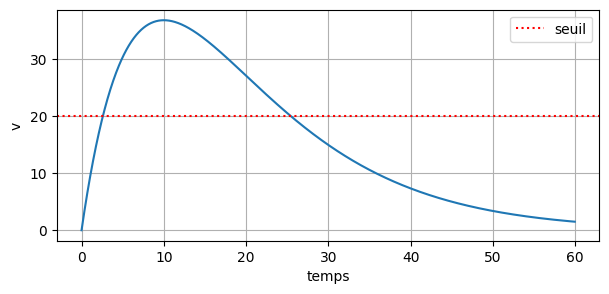

seuil franchi apres 51 iterations, a t = 2.6


In [1]:
import numpy as np
import matplotlib.pyplot as plt

A     = 10.0     # amplitude du signal
tau   = 10.0     # temps caracteristique
dt    = 0.05     # pas de temps
seuil = 20.0     # seuil a detecter

# allure de la quantite observee (calcul direct, sans boucle)
t = np.arange(0, 60, dt)
plt.figure(figsize=(7,3))
plt.plot(t, A*t*np.exp(-t/tau))
plt.axhline(seuil, color='r', linestyle=':', label='seuil')
plt.xlabel('temps')
plt.ylabel('v')
plt.legend()
plt.grid(True)
plt.show()

# la boucle s'arrete des que le seuil est franchi
temps = 0.0
for it in range(100000):                  # borne de securite
    temps += dt
    v = A * temps * np.exp(-temps/tau)
    if v > seuil:
        break

print("seuil franchi apres", it, "iterations, a t =", round(temps, 2))

## 2. Retenir une valeur sans arrêter : le drapeau

Souvent, on ne veut **pas** arrêter le modèle : on note l'instant de l'événement et la simulation continue. Le réflexe naturel,

```python
if v > seuil:
    t_seuil = temps
```

est **faux** : la condition reste vraie aux itérations suivantes, donc `t_seuil` est réécrit à chaque tour et retient le **dernier** instant au-dessus du seuil, pas le premier.

La solution est un **drapeau**, qui retient que l'événement a déjà eu lieu :

```python
flag = 0                            # avant la boucle

if v > seuil and flag == 0:         # dans la boucle
    t_seuil = temps
    flag = 1                        # on ne repassera plus ici
```

Il sert aussi **après** la boucle : `if flag == 1:` avant d'annoncer le résultat, sinon on affiche une valeur pour un événement qui ne s'est jamais produit.

## 3. Comparer avec l'itération précédente

Certains événements ne se lisent pas sur la valeur courante seule. Pour repérer le **maximum**, il faut savoir si la quantité vient de commencer à diminuer — donc conserver la valeur du pas précédent, à la fin de chaque tour : `v_prec = v`.

> ⚠️ **Si la quantité comparée est un tableau**, `v_prec = v` ne suffit plus : cette écriture ne copie que l'**adresse**, les deux noms désignent le même tableau, et la différence vaudrait toujours zéro. Il faut alors une copie physique — `T_prec = np.copy(T)` au début du tour, puis `if np.sum(np.abs(T_prec - T)) < tol: break`. C'est la forme du critère d'état stationnaire, que vous retrouverez au cours 5.

Le code ci-dessous réunit les trois mécanismes. `choix = 1` utilise le drapeau, `choix = 2` s'en passe. Exécutez la cellule, puis passez `choix` à `2`.

In [2]:
choix = 1       # <<< CHANGEZ CETTE LIGNE :  1 -> avec drapeau   ou   2 -> sans drapeau

tol = 1e-6      # en dessous, on considere que la quantite n'evolue plus

temps      = 0.0
flag_seuil = 0
flag_max   = 0
t_seuil    = 0.0
t_max      = 0.0
v_prec     = 0.0

for it in range(100000):                  # borne de securite

    temps += dt
    v = A * temps * np.exp(-temps/tau)

    # 1) premier passage au-dessus du seuil
    if choix == 1:
        if v > seuil and flag_seuil == 0:
            t_seuil = temps
            flag_seuil = 1
    else:
        if v > seuil:
            t_seuil = temps

    # 2) instant du maximum : il faut la valeur du pas precedent
    if v < v_prec and v > seuil and flag_max == 0:
        t_max = temps
        flag_max = 1

    # 3) arret quand la quantite n'evolue plus
    if abs(v - v_prec) < tol and temps > tau:
        break

    v_prec = v                            # a la fin du tour, pour le tour suivant

print("arret apres", it, "iterations, a t =", round(temps, 1))
print("passage au seuil :", round(t_seuil, 2))
if flag_max == 1:
    print("maximum atteint  :", round(t_max, 2))

arret apres 3164 iterations, a t = 158.3
passage au seuil : 2.6
maximum atteint  : 10.05


Avec `choix = 1`, le seuil est daté à **t = 2.60** et le maximum à **t = 10.05** : l'ordre est cohérent.

Avec `choix = 2`, le seuil est daté à **t = 25.40**, soit **après** le maximum — ce qui n'a aucun sens. Sans drapeau, `t_seuil` retient le moment où la quantité est *redescendue* sous le seuil.

**Rien n'a explosé** : même nombre d'itérations, valeur plausible. Seule la confrontation des deux dates révèle l'erreur.